# K Nearest Neighbors

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

## Importing Dataset

In [67]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# Load Iris dataset
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df_original = df.copy()

Dataset loaded successfully!
Shape: (150, 6)


## Basic Data Representation

In [68]:
# Display first few rows
print("First 5 rows of the dataset:")
print(df.head())
print("\n" + "="*80 + "\n")

# Display last few rows
print("Last 5 rows of the dataset:")
print(df.tail())
print("\n" + "="*80 + "\n")

# Dataset information
print("Dataset Information:")
print(df.info())
print("\n" + "="*80 + "\n")

# Statistical summary
print("Statistical Summary:")
print(df.describe())
print("\n" + "="*80 + "\n")

# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print("\n" + "="*80 + "\n")

# Target distribution
print("Target Distribution:")
print(df['species'].value_counts())
print("\nTarget Distribution (%):")
print(df['species'].value_counts(normalize=True) * 100)

First 5 rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  


Last 5 rows of the dataset:
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2

## Exploratory Data Analysis (EDA)

### Correlation Analysis

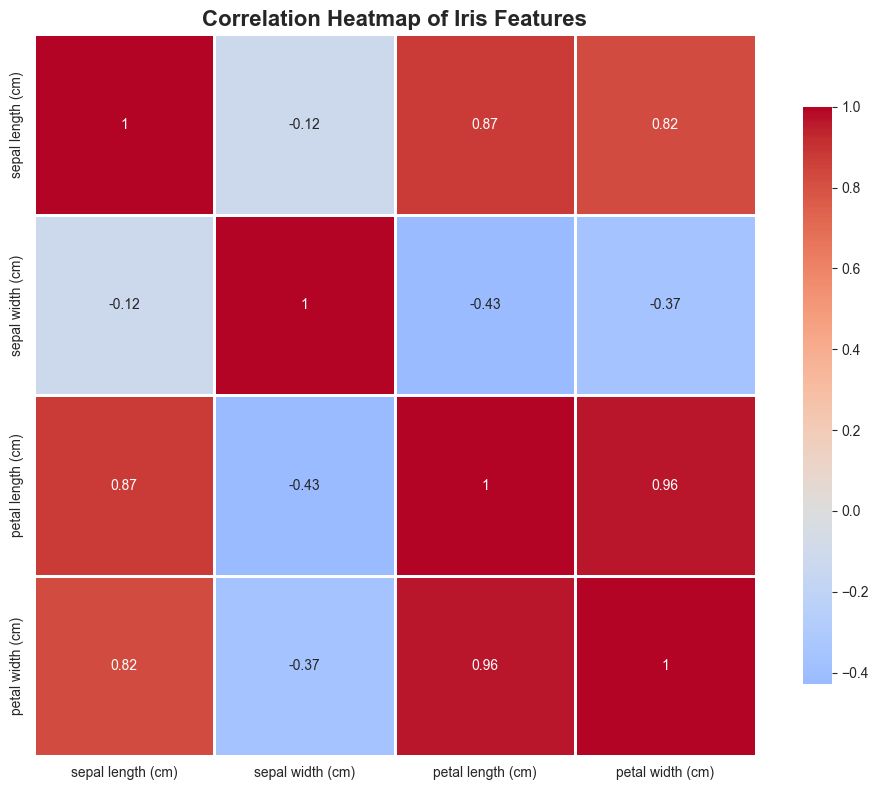

In [69]:
# Correlation matrix for numerical features
plt.figure(figsize=(10, 8))
correlation_matrix = df.iloc[:, :-2].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Iris Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Pairplot Analysis

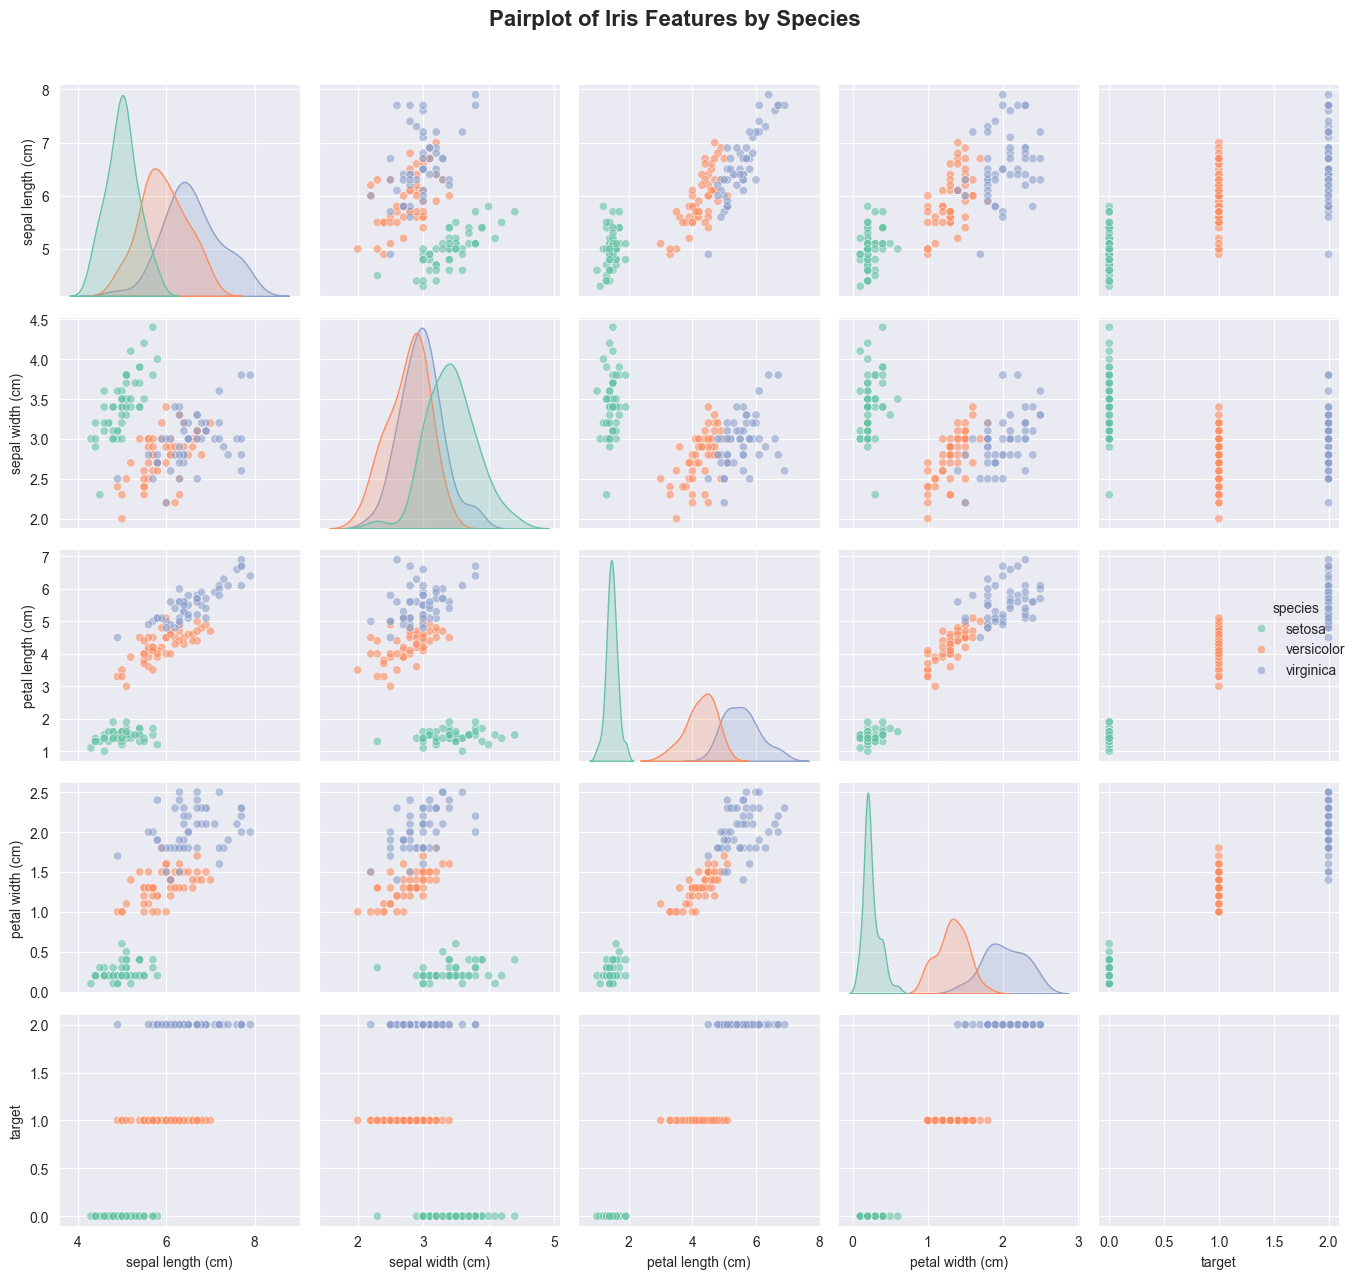

In [70]:
# Pairplot to visualize relationships between features
sns.pairplot(df, hue='species', diag_kind='kde', palette='Set2',
             plot_kws={'alpha': 0.6}, height=2.5)
plt.suptitle('Pairplot of Iris Features by Species', y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Distribution Analysis

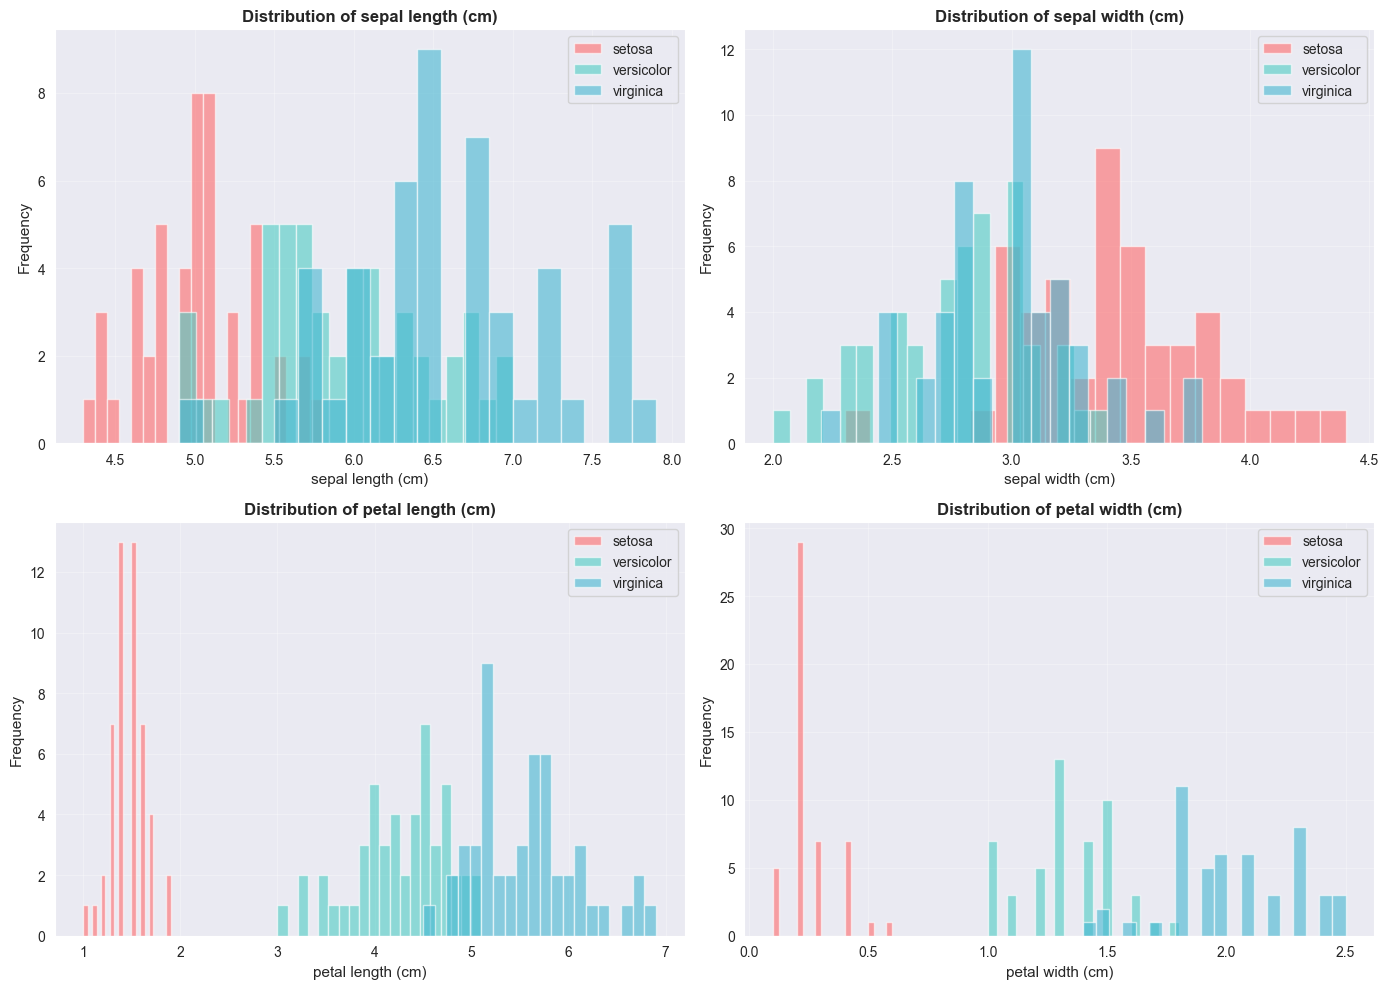

In [71]:
# Distribution plots for each feature
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for idx, col in enumerate(iris.feature_names):
    ax = axes[idx // 2, idx % 2]
    for i, species in enumerate(df['species'].unique()):
        data = df[df['species'] == species][col]
        ax.hist(data, alpha=0.6, label=species, bins=20, color=colors[i])
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Box Plot Analysis

/var/folders/kc/jh1xkqxn3vdd35xtydf9ktqc0000gn/T/ipykernel_66728/1026791617.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=col, ax=ax, palette='Set2')
/var/folders/kc/jh1xkqxn3vdd35xtydf9ktqc0000gn/T/ipykernel_66728/1026791617.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=col, ax=ax, palette='Set2')
/var/folders/kc/jh1xkqxn3vdd35xtydf9ktqc0000gn/T/ipykernel_66728/1026791617.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=col, ax=ax, palette='Set2')
/var/fo

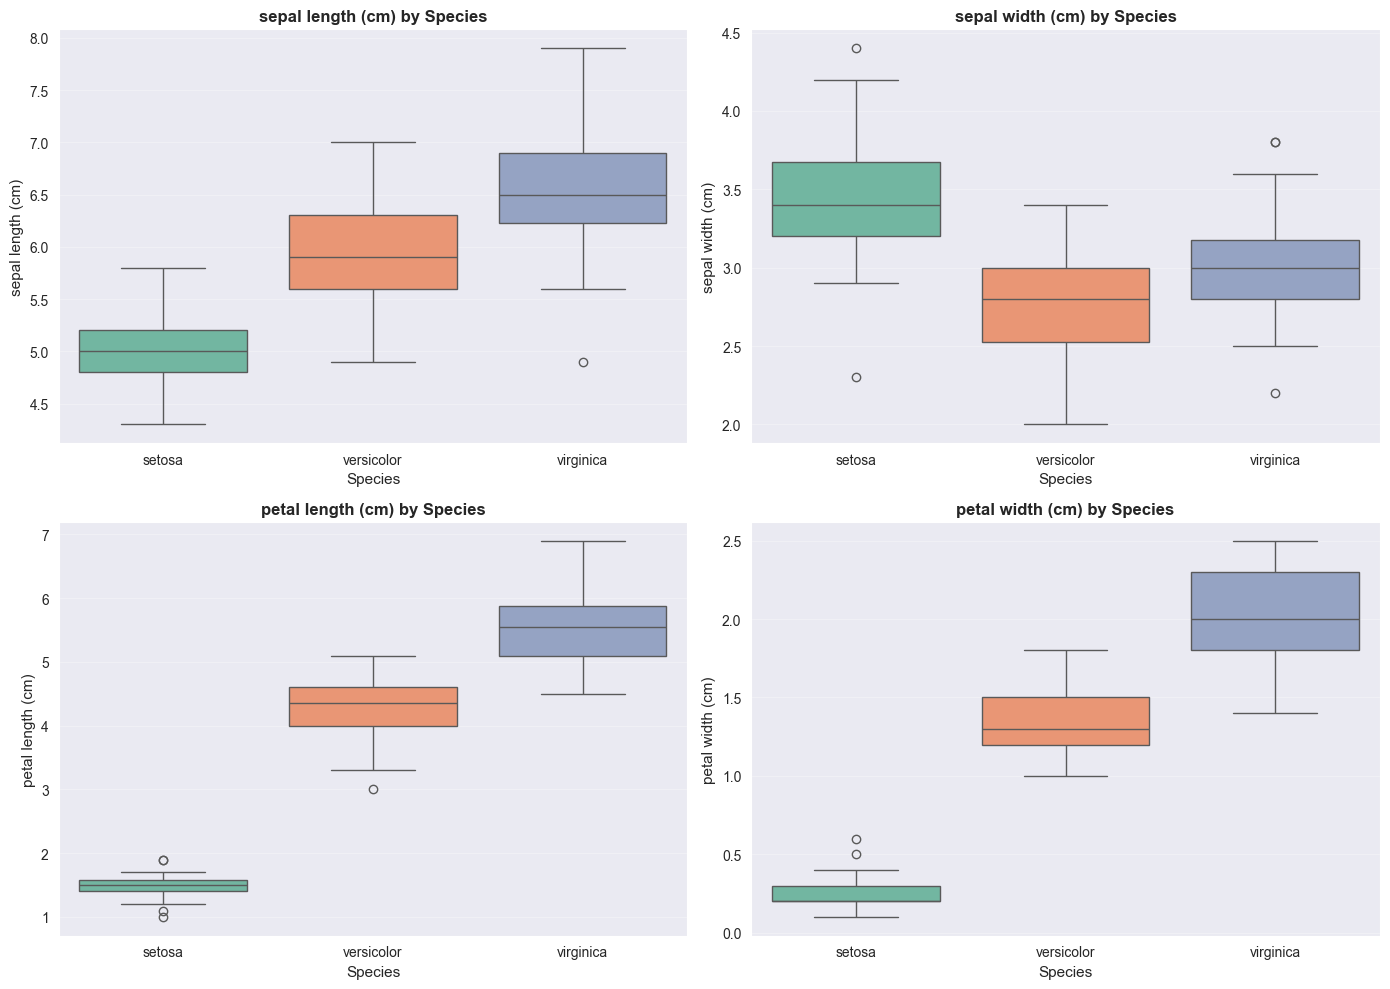

In [72]:
# Box plots to identify outliers and compare distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, col in enumerate(iris.feature_names):
    ax = axes[idx // 2, idx % 2]
    sns.boxplot(data=df, x='species', y=col, ax=ax, palette='Set2')
    ax.set_title(f'{col} by Species', fontsize=12, fontweight='bold')
    ax.set_xlabel('Species', fontsize=11)
    ax.set_ylabel(col, fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Second Degree Treatment

### Outlier Detection and Removal Groupwise

In [73]:
# Outlier Detection and Removal using Groupwise IQR Method
# This computes IQR bounds per species group instead of globally

df_grouped_clean = df_original.copy()

print(f"Original dataset shape: {df_original.shape}")
print(f"Number of rows before groupwise outlier removal: {len(df_original)}")


def remove_outliers_groupwise(data, features, group_col='species'):
    """Remove outliers using IQR method computed within each group."""
    mask = pd.Series(True, index=data.index)

    for col in features:
        for group in data[group_col].unique():
            group_mask = data[group_col] == group
            group_data = data.loc[group_mask, col]

            Q1 = group_data.quantile(0.25)
            Q3 = group_data.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            # Mark rows that are outliers within this group
            outlier_mask = group_mask & ((data[col] < lower_bound) | (data[col] > upper_bound))
            mask = mask & ~outlier_mask

            n_outliers = outlier_mask.sum()
            if n_outliers > 0:
                print(f"  {col} | {group}: {n_outliers} outlier(s) removed "
                      f"(bounds: [{lower_bound:.4f}, {upper_bound:.4f}])")

    return data[mask]


print("\nOutliers detected per feature and species group:")
print("-" * 70)
df_grouped_clean = remove_outliers_groupwise(df_original, iris.feature_names, group_col='species')

print("\n" + "=" * 80)
print(f"\nCleaned dataset shape (groupwise): {df_grouped_clean.shape}")
print(f"Number of rows after groupwise outlier removal: {len(df_grouped_clean)}")
print(f"Number of rows removed: {len(df_original) - len(df_grouped_clean)}")

# Reset index
df_grouped_clean = df_grouped_clean.reset_index(drop=True)

print("\n" + "=" * 80)
print("\nGroupwise Cleaned Dataset - First 10 rows:")
df_grouped_clean.head(10)


Original dataset shape: (150, 6)
Number of rows before groupwise outlier removal: 150

Outliers detected per feature and species group:
----------------------------------------------------------------------
  sepal length (cm) | virginica: 1 outlier(s) removed (bounds: [5.2125, 7.9125])
  sepal width (cm) | setosa: 2 outlier(s) removed (bounds: [2.4875, 4.3875])
  sepal width (cm) | virginica: 3 outlier(s) removed (bounds: [2.2375, 3.7375])
  petal length (cm) | setosa: 4 outlier(s) removed (bounds: [1.1375, 1.8375])
  petal length (cm) | versicolor: 1 outlier(s) removed (bounds: [3.1000, 5.5000])
  petal width (cm) | setosa: 2 outlier(s) removed (bounds: [0.0500, 0.4500])


Cleaned dataset shape (groupwise): (137, 6)
Number of rows after groupwise outlier removal: 137
Number of rows removed: 13


Groupwise Cleaned Dataset - First 10 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
5,5.4,3.9,1.7,0.4,0,setosa
6,4.6,3.4,1.4,0.3,0,setosa
7,5.0,3.4,1.5,0.2,0,setosa
8,4.4,2.9,1.4,0.2,0,setosa
9,4.9,3.1,1.5,0.1,0,setosa


/var/folders/kc/jh1xkqxn3vdd35xtydf9ktqc0000gn/T/ipykernel_66728/2699781055.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_grouped_clean, x='species', y=col, ax=ax, palette='Set2')
/var/folders/kc/jh1xkqxn3vdd35xtydf9ktqc0000gn/T/ipykernel_66728/2699781055.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_grouped_clean, x='species', y=col, ax=ax, palette='Set2')
/var/folders/kc/jh1xkqxn3vdd35xtydf9ktqc0000gn/T/ipykernel_66728/2699781055.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_grouped_clean, x='speci

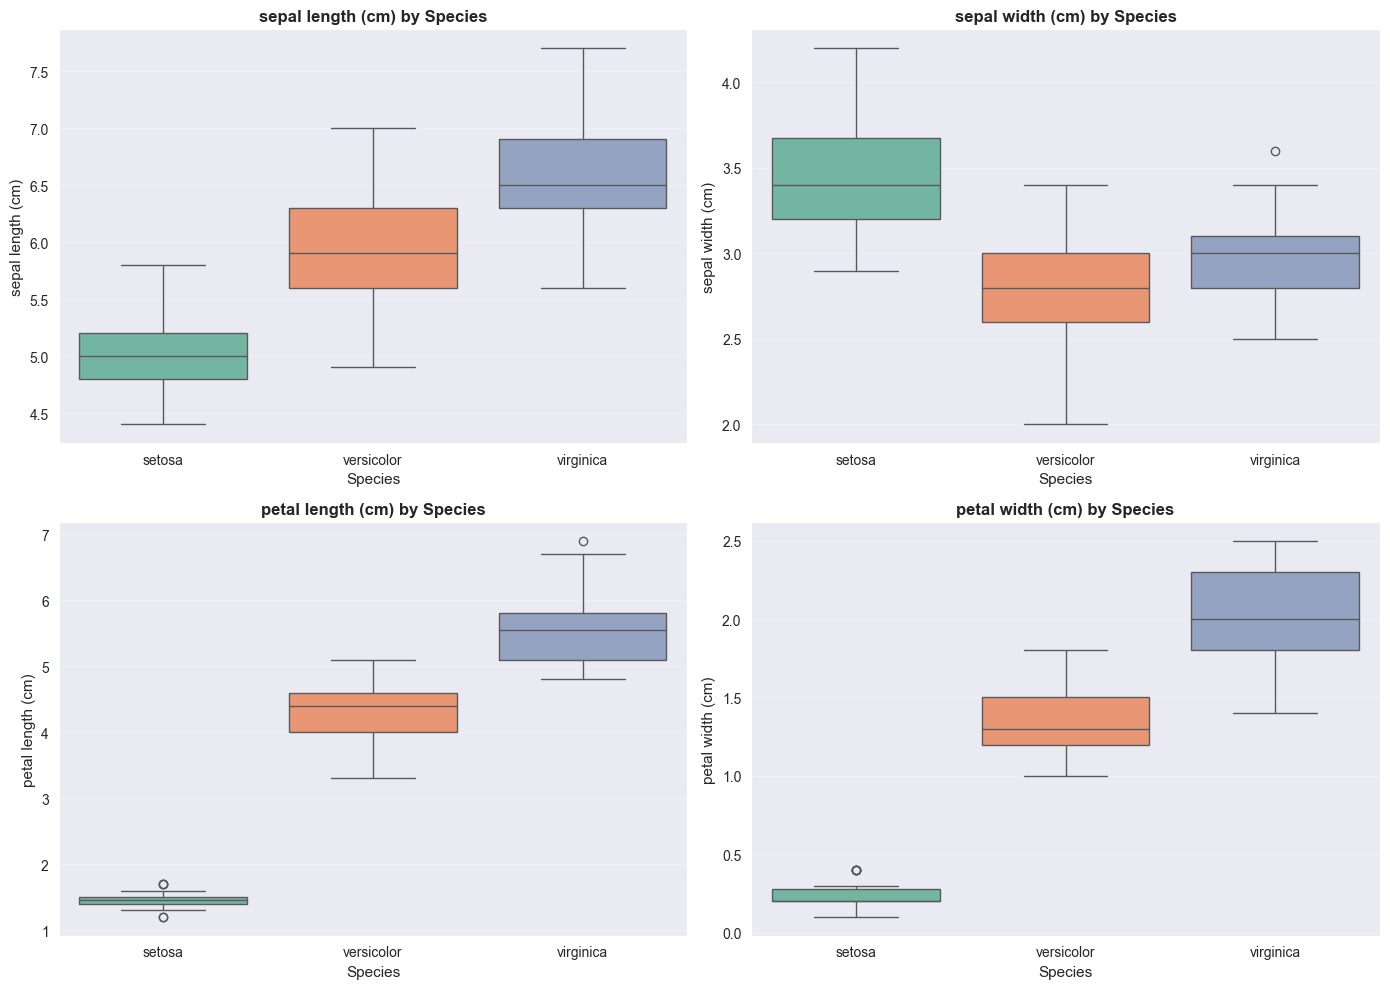

In [74]:
# Box plots to identify outliers and compare distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, col in enumerate(iris.feature_names):
    ax = axes[idx // 2, idx % 2]
    sns.boxplot(data=df_grouped_clean, x='species', y=col, ax=ax, palette='Set2')
    ax.set_title(f'{col} by Species', fontsize=12, fontweight='bold')
    ax.set_xlabel('Species', fontsize=11)
    ax.set_ylabel(col, fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Training the Model

In [75]:
# Apply StandardScaler to the feature data
X = df_grouped_clean[iris.feature_names].values
y = df_grouped_clean['target'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create a scaled DataFrame for reference
df_scaled = pd.DataFrame(X_scaled, columns=iris.feature_names)
df_scaled['target'] = y
df_scaled['species'] = df_grouped_clean['species'].values

print("StandardScaler applied successfully!")


StandardScaler applied successfully!


In [76]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Split the scaled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Initialize and train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred = knn.predict(X_test)

# Evaluate the model
print("KNN Model Results on Scaled Data")
print("=" * 60)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred, target_names=iris.target_names)}")


KNN Model Results on Scaled Data

Accuracy: 92.86%

Confusion Matrix:
[[14  0  0]
 [ 0 12  2]
 [ 0  1 13]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        14
  versicolor       0.92      0.86      0.89        14
   virginica       0.87      0.93      0.90        14

    accuracy                           0.93        42
   macro avg       0.93      0.93      0.93        42
weighted avg       0.93      0.93      0.93        42



## Third Degree Treatment

### Outliear Detection and Removal

In [77]:
print(f"Dataset shape after second degree treatment: {df_grouped_clean.shape}")
print(f"Number of rows before third degree outlier removal: {len(df_grouped_clean)}")


def remove_outliers_third_degree(data, features, group_col='species', multiplier=3.0):
    """Remove outliers using IQR method with a 3x multiplier (third degree) computed within each group."""
    mask = pd.Series(True, index=data.index)

    for col in features:
        for group in data[group_col].unique():
            group_mask = data[group_col] == group
            group_data = data.loc[group_mask, col]

            Q1 = group_data.quantile(0.05)
            Q3 = group_data.quantile(0.95)

            lower_bound = Q1
            upper_bound = Q3

            # Mark rows that are outliers within this group
            outlier_mask = group_mask & ((data[col] < lower_bound) | (data[col] > upper_bound))
            mask = mask & ~outlier_mask

            n_outliers = outlier_mask.sum()
            if n_outliers > 0:
                print(f"  {col} | {group}: {n_outliers} outlier(s) removed "
                      f"(bounds: [{lower_bound:.4f}, {upper_bound:.4f}])")

    return data[mask]


print("\nOutliers detected per feature and species group (3rd degree, multiplier=3.0):")
print("-" * 70)
df_third_degree_clean = remove_outliers_third_degree(df_original, iris.feature_names, group_col='species')

print("\n" + "=" * 80)
print(f"\nCleaned dataset shape (third degree): {df_third_degree_clean.shape}")
print(f"Number of rows after third degree outlier removal: {len(df_third_degree_clean)}")
print(f"Number of rows removed: {len(df_grouped_clean) - len(df_third_degree_clean)}")

# Reset index
df_third_degree_clean = df_third_degree_clean.reset_index(drop=True)

print("\n" + "=" * 80)
print("\nThird Degree Cleaned Dataset - First 10 rows:")
df_third_degree_clean.head(10)


Dataset shape after second degree treatment: (137, 6)
Number of rows before third degree outlier removal: 137

Outliers detected per feature and species group (3rd degree, multiplier=3.0):
----------------------------------------------------------------------
  sepal length (cm) | setosa: 4 outlier(s) removed (bounds: [4.4000, 5.6100])
  sepal length (cm) | versicolor: 6 outlier(s) removed (bounds: [5.0450, 6.7550])
  sepal length (cm) | virginica: 4 outlier(s) removed (bounds: [5.7450, 7.7000])
  sepal width (cm) | setosa: 5 outlier(s) removed (bounds: [3.0000, 4.0550])
  sepal width (cm) | versicolor: 5 outlier(s) removed (bounds: [2.2450, 3.2000])
  sepal width (cm) | virginica: 4 outlier(s) removed (bounds: [2.5000, 3.5100])
  petal length (cm) | setosa: 4 outlier(s) removed (bounds: [1.2000, 1.7000])
  petal length (cm) | versicolor: 5 outlier(s) removed (bounds: [3.3900, 4.9000])
  petal length (cm) | virginica: 6 outlier(s) removed (bounds: [4.8450, 6.6550])
  petal width (cm) |

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
5,5.4,3.9,1.7,0.4,0,setosa
6,4.6,3.4,1.4,0.3,0,setosa
7,5.0,3.4,1.5,0.2,0,setosa
8,4.9,3.1,1.5,0.1,0,setosa
9,5.4,3.7,1.5,0.2,0,setosa


### Training the Model

In [78]:
# Apply StandardScaler to the feature data
X = df_third_degree_clean[iris.feature_names].values
y = df_third_degree_clean['target'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create a scaled DataFrame for reference
df_scaled = pd.DataFrame(X_scaled, columns=iris.feature_names)
df_scaled['target'] = y
df_scaled['species'] = df_third_degree_clean['species'].values

print("StandardScaler applied successfully!")

StandardScaler applied successfully!


In [79]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Split the scaled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Initialize and train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred = knn.predict(X_test)

# Evaluate the model
print("KNN Model Results on Scaled Data")
print("=" * 60)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred, target_names=iris.target_names)}")


KNN Model Results on Scaled Data

Accuracy: 100.00%

Confusion Matrix:
[[13  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        33
   macro avg       1.00      1.00      1.00        33
weighted avg       1.00      1.00      1.00        33

